In [18]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
import argparse
from pathlib import Path
from argparse import Namespace

from sklearn.model_selection import train_test_split

#torch.set_float32_matmul_precision('high')  # allows TF32
#torch.backends.cuda.matmul.allow_tf32 = True
#torch.backends.cudnn.allow_tf32 = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

from train_sm import MakeDataset, create_data_loaders, EarlyStopping
from sm import NeuralNet

args = Namespace(
    data_dir=Path(f"/gpfs/bwfor/work/ws/hd_gy283-my_data/data_uni_n_a=50/"),
    num_batches=280,
    batch_size=512,
    x_mean=None,
    x_std=None,
    y_mean=None,
    y_std=None,
    layer_dims=[7, 60, 60, 60, 1],
    num_epochs=300,
    lr=1e-3,
    save_name=Path(f"/home/hd/hd_hd/hd_gy283/kmc_project/models/sm_uni_n_a=50_1e7"),
)

train_loader, test_loader, x_mean, x_std, y_mean, y_std = create_data_loaders(args.data_dir, args.num_batches, args.batch_size)
args.x_mean = x_mean
args.x_std = x_std
args.y_mean = y_mean
args.y_std = y_std
print(args)

cuda
raw_inputs shape: (280000, 8)
outputs shape: (280000,)
inputs shape: (280000, 7)
Namespace(data_dir=PosixPath('/gpfs/bwfor/work/ws/hd_gy283-my_data/data_uni_n_a=50'), num_batches=280, batch_size=512, x_mean=array([ 5.60211903e-04, -1.30424568e-03,  1.23286849e-03,  9.02192286e-05,
       -4.82197606e-04, -2.98614126e-04,  8.46599135e-04]), x_std=array([0.8663518 , 0.86561167, 0.86639286, 0.86581593, 0.86592347,
       0.86623204, 0.86626736]), y_mean=-0.00047953607655628103, y_std=0.011341177478543721, layer_dims=[7, 60, 60, 60, 1], num_epochs=300, lr=0.001, save_name=PosixPath('/home/hd/hd_hd/hd_gy283/kmc_project/models/sm_uni_n_a=50_1e7'))


In [19]:
model = NeuralNet(args.layer_dims, args.x_mean, args.x_std, args.y_mean, args.y_std).to(device)
#model = torch.compile(model)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=args.lr)
#scheduler = torch.optim.lr_scheduler.StepLR(optimizer=optimizer, step_size=200, gamma=0.1)
#scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=100, T_mult=2, eta_min=1e-6)

train_losses = []
val_losses = []

early_stopping = EarlyStopping(patience=10, min_delta=0.0001)

for epoch in range(1, args.num_epochs+1):

    model.train()
    running_loss = 0.0
    for inputs_batch, targets_batch in train_loader:
        inputs_batch  = inputs_batch.to(device, non_blocking=True).float()
        targets_batch = targets_batch.to(device, non_blocking=True).float()

        optimizer.zero_grad()
        preds = model(inputs_batch)
        preds = (preds - model.y_mean) / model.y_std
        targets_batch = (targets_batch - model.y_mean) / model.y_std
        loss  = criterion(preds, targets_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs_batch.size(0)

    epoch_train_loss = running_loss / len(train_loader.dataset)

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for inputs_batch, targets_batch in test_loader:
            inputs_batch  = inputs_batch.to(device, non_blocking=True).float()
            targets_batch = targets_batch.to(device, non_blocking=True).float()

            preds = model(inputs_batch)
            preds = (preds - model.y_mean) / model.y_std
            targets_batch = (targets_batch - model.y_mean) / model.y_std
            loss  = criterion(preds, targets_batch)
            val_loss += loss.item() * inputs_batch.size(0)

    epoch_val_loss = val_loss / len(test_loader.dataset)
    #scheduler.step()

    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)
    #current_lr = optimizer.param_groups[0]['lr']
    if epoch % 10 == 0:
        print(f"Epoch {epoch:2d}/{args.num_epochs} "
              f"   Train Loss: {epoch_train_loss:.10f}"
              f"   Val Loss: {epoch_val_loss:.10f}", flush=True)
    #early_stopping(epoch_val_loss)
    if early_stopping.early_stop:
        print("[EARLY STOPPING TRIGGERED]")
        break

torch.save({
    "model_state_dict": model.state_dict(),
    "args": vars(args),
    "train_losses": train_losses,
    "val_losses": val_losses
}, f"{args.save_name}.pth")

print(f"Model has been saved!")

Epoch 10/300    Train Loss: 0.0310078514   Val Loss: 0.0278990763
Epoch 20/300    Train Loss: 0.0211702463   Val Loss: 0.0190086052
Epoch 30/300    Train Loss: 0.0160488171   Val Loss: 0.0166623487
Epoch 40/300    Train Loss: 0.0143784145   Val Loss: 0.0145033986
Epoch 50/300    Train Loss: 0.0136869107   Val Loss: 0.0135078725
Epoch 60/300    Train Loss: 0.0132412864   Val Loss: 0.0137775101
Epoch 70/300    Train Loss: 0.0130909108   Val Loss: 0.0125008038
Epoch 80/300    Train Loss: 0.0125534483   Val Loss: 0.0139293234
Epoch 90/300    Train Loss: 0.0123019741   Val Loss: 0.0128852850
Epoch 100/300    Train Loss: 0.0122813492   Val Loss: 0.0124969276
Epoch 110/300    Train Loss: 0.0122758411   Val Loss: 0.0123991211
Epoch 120/300    Train Loss: 0.0120860966   Val Loss: 0.0130581233
Epoch 130/300    Train Loss: 0.0119564543   Val Loss: 0.0127461056
Epoch 140/300    Train Loss: 0.0119866175   Val Loss: 0.0133223273
Epoch 150/300    Train Loss: 0.0119077208   Val Loss: 0.0124305227
Epoc

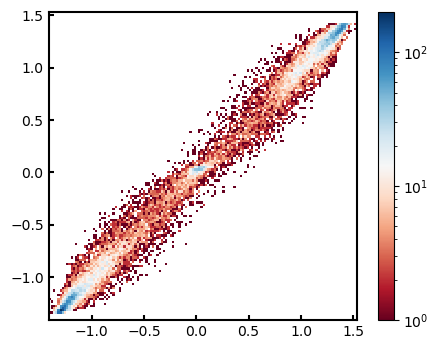

In [17]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from sm import NeuralNet

state_dict = torch.load("/home/hd/hd_hd/hd_gy283/kmc_project/models/sm_uni_n_a=50_1e7.pth", map_location="cpu", weights_only=False)
args = state_dict['args']
model_state_dict = state_dict['model_state_dict']

net = NeuralNet(args['layer_dims'], args['x_mean'], args['x_std'], args['y_mean'], args['y_std'])
net.load_state_dict(model_state_dict)

y_true = []

net.eval()

num_batches = 300
y_true_list = []
x_in = []

for i in range(280, num_batches):
    data = np.load(f"/gpfs/bwfor/work/ws/hd_gy283-my_data/data_uni_n_a=50/batch_{i}.npz")
    output_idx = data["outputIdx"][0]
    x, y = data["inputs"], data["currents"]
    x_in.append(x[:, output_idx+1:])
    y_true_list.append(y)

input_tensor = torch.tensor(np.concatenate(x_in, axis=0), dtype=torch.float32)

with torch.no_grad():
    y_pred = net(input_tensor).detach().cpu()
y_true = np.concatenate(y_true_list, axis=0)[:, None]

y_pred = (y_pred - net.y_mean.numpy()) / net.y_std.numpy()
y_true = (y_true - net.y_mean.numpy()) / net.y_std.numpy()

l_bound = -1.5
u_bound = 1.5
#z = l_bound + (u_bound - l_bound) * torch.rand(num_points, net.layer_dims[0])

def pred_vs_true(y_pred, y_true, bins=140, use_log=True):

    y_pred = np.asarray(y_pred).ravel()
    y_true = np.asarray(y_true).ravel()

    pad = 0.001
    min_val = float(min(y_true.min(),y_pred.min()))
    max_val = float(max(y_true.max(),y_pred.max()))

    norm = LogNorm()

    fig, ax = plt.subplots(figsize=(4,4))

    _, _, _, im = ax.hist2d(y_pred, y_true, bins=bins, range=[[min_val, max_val], [min_val, max_val]], norm=norm, cmap="RdBu")
    cax = fig.add_axes([ax.get_position().x1 + 0.05, ax.get_position().y0, 0.04, ax.get_position().height])
    plt.colorbar(im, cax=cax)
    #ax.scatter(y_pred, y_true, s=4, edgecolors="blue", facecolor=None)
    ax.spines[:].set_linewidth(1.5)
    ax.tick_params(which='major', direction='in', width=1.5)
    ax.set_aspect('equal')

    #ax.plot([min_val, min_val], [max_val, max_val])

pred_vs_true(y_pred, y_true)